In [1]:
# -------------------------------------------------------------------------
# Step 1: Data Ingestion, Cleaning & Feature Engineering
# -------------------------------------------------------------------------
import os
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# 1. Load dataset from Kaggle input directory
DATASET_DIR = "/kaggle/input/datasets/chethuhn/network-intrusion-dataset"
csv_files   = glob.glob(os.path.join(DATASET_DIR, "*.csv"))
print(f"📁 Found {len(csv_files)} CSV file(s).")

df_list = []
for file_path in csv_files:
    filename = os.path.basename(file_path)
    print(f"   Reading: {filename}...")
    sub_df = pd.read_csv(file_path, low_memory=False)
    if len(sub_df) > 40000:
        sub_df = sub_df.sample(n=40000, random_state=SEED)
    df_list.append(sub_df)

df = pd.concat(df_list, axis=0, ignore_index=True)

# 2. Clean column names
df.columns = df.columns.str.strip()
target_col = "Label" if "Label" in df.columns else df.columns[-1]

# 3. Drop identifier columns
cols_to_drop = [c for c in [
    "Flow ID", "Source IP", "Source Port",
    "Destination IP", "Destination Port",
    "Timestamp", "Unnamed: 0"
] if c in df.columns]
df = df.drop(columns=cols_to_drop)

# 4. Handle infinities and NaNs
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# 5. Features and labels
X_raw = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values
y_raw = df[target_col].astype(str).values

# 6. Encode attack class labels (multi-class — all 15 classes)
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
num_classes = len(le.classes_)
class_names = list(le.classes_)

print(f"\n📊 Attack Classes ({num_classes} total):")
for i, cls in enumerate(class_names):
    count = (y_encoded == i).sum()
    print(f"   [{i:02d}] {cls:<40} {count:>7,} samples")

# 7. Remove classes with too few samples before splitting
from collections import Counter

class_counts = Counter(y_encoded)
# Keep only classes with at least 10 samples
valid_classes = {cls for cls, cnt in class_counts.items() if cnt >= 10}
mask          = np.array([y in valid_classes for y in y_encoded])

X_raw    = X_raw[mask]
y_encoded = y_encoded[mask]

# Re-encode labels cleanly after filtering
le        = LabelEncoder()
y_encoded = le.fit_transform([class_names[y] for y in y_encoded])
class_names = list(le.classes_)
num_classes = len(class_names)

print(f"\n📊 Filtered Classes ({num_classes} total, min 10 samples each):")
for i, cls in enumerate(class_names):
    count = (y_encoded == i).sum()
    print(f"   [{i:02d}] {cls:<40} {count:>7,} samples")

# 8. Train / validation / test split (stratified — safe now)
X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_encoded, test_size=0.3, random_state=SEED, stratify=y_encoded
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

# 9. Scale + clip
scaler      = StandardScaler()
X_train     = np.clip(scaler.fit_transform(X_train_raw), -5, 5)
X_val       = np.clip(scaler.transform(X_val_raw),       -5, 5)
X_test      = np.clip(scaler.transform(X_test_raw),      -5, 5)

print(f"\n✅ Step 1 Execution Completed:")
print(f"   Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")

📁 Found 8 CSV file(s).
   Reading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
   Reading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
   Reading: Tuesday-WorkingHours.pcap_ISCX.csv...
   Reading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
   Reading: Monday-WorkingHours.pcap_ISCX.csv...
   Reading: Friday-WorkingHours-Morning.pcap_ISCX.csv...
   Reading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
   Reading: Wednesday-workingHours.pcap_ISCX.csv...

📊 Attack Classes (15 total):
   [00] BENIGN                                   258,121 samples
   [01] Bot                                          382 samples
   [02] DDoS                                      22,808 samples
   [03] DoS GoldenEye                                565 samples
   [04] DoS Hulk                                  13,203 samples
   [05] DoS Slowhttptest                             329 samples
   [06] DoS slowloris                                327 samples
   [07]

In [3]:
# -------------------------------------------------------------------------
# Step 2: PyTorch DataLoaders & Transformer Architecture
# -------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Device: {device}")

# 1. Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# 2. DataLoaders
BATCH_SIZE   = 256
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False)


# 3. Transformer Architecture (TabTransformer for network traffic)
class CyberTransformer(nn.Module):
    """
    TabTransformer for network traffic attack classification.

    Architecture:
        Feature Embedding : Projects each scalar feature → d_model dimensions
        Transformer Encoder: Multi-head self-attention (learns feature relationships)
        Classifier Head   : Classifies into 15 attack types

    Key insight:
        Each network feature (flow duration, packet size, etc.)
        becomes a "token" — attention learns which features
        are most important for identifying each attack type.
    """

    def __init__(self, input_dim, num_classes,
                 d_model=64, nhead=4, num_layers=3, dropout=0.1):
        super(CyberTransformer, self).__init__()

        self.d_model   = d_model
        self.input_dim = input_dim

        # Project each scalar feature to d_model dimensions
        self.feature_embedding = nn.Sequential(
            nn.Linear(1, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU()
        )

        # Learnable positional encoding for each feature position
        self.pos_embedding = nn.Parameter(
            torch.randn(1, input_dim, d_model) * 0.1
        )

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = nhead,
            dim_feedforward= d_model * 4,
            dropout        = dropout,
            batch_first    = True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(d_model * input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (B, input_dim)
        B = x.size(0)

        # Embed each feature: (B, D) → (B, D, 1) → (B, D, d_model)
        x = x.unsqueeze(-1)                              # (B, D, 1)
        x = self.feature_embedding(x)                    # (B, D, d_model)

        # Add positional encoding
        x = x + self.pos_embedding                       # (B, D, d_model)

        # Transformer encoder
        x = self.transformer(x)                          # (B, D, d_model)

        # Flatten and classify
        x = x.reshape(B, -1)                            # (B, D * d_model)
        logits = self.classifier(x)                      # (B, num_classes)

        return logits

# 4. Instantiate
input_dim = X_train.shape[1]
model     = CyberTransformer(
    input_dim   = input_dim,
    num_classes = num_classes,
    d_model     = 64,
    nhead       = 4,
    num_layers  = 3,
    dropout     = 0.1
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n✅ Step 2 Execution Completed:")
print(f"   Input Dim       : {input_dim}")
print(f"   Classes         : {num_classes}")
print(f"   d_model         : 64 | Heads: 4 | Layers: 3")
print(f"   Total Params    : {total_params:,}")




⚡ Device: cuda

✅ Step 2 Execution Completed:
   Input Dim       : 77
   Classes         : 12
   d_model         : 64 | Heads: 4 | Layers: 3
   Total Params    : 2,747,020


In [4]:
# -------------------------------------------------------------------------
# Step 3: Training Loop
# -------------------------------------------------------------------------
import time

EPOCHS        = 30
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

train_losses, val_losses     = [], []
train_accs,   val_accs       = [], []
best_val_acc  = 0.0

print(f"🚀 Training CyberTransformer for {EPOCHS} Epochs on {device.type.upper()}...")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # ── Training Phase ────────────────────────────────────────
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)

        logits = model(x_b)
        loss   = criterion(logits, y_b)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        preds          = logits.argmax(dim=1)
        total_correct += (preds == y_b).sum().item()
        total_samples += y_b.size(0)
        total_loss    += loss.item()

    avg_train_loss = total_loss   / len(train_loader)
    avg_train_acc  = total_correct / total_samples
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)
    # ── Validation Phase ──────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for x_v, y_v in val_loader:
            x_v, y_v = x_v.to(device), y_v.to(device)
            logits   = model(x_v)
            val_loss += criterion(logits, y_v).item()
            preds     = logits.argmax(dim=1)
            val_correct += (preds == y_v).sum().item()
            val_total   += y_v.size(0)

    avg_val_loss = val_loss     / len(val_loader)
    avg_val_acc  = val_correct  / val_total
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)

    scheduler.step(avg_val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    # Save best model
    status = ""
    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        torch.save(model.state_dict(), 'best_transformer.pth')
        status = "✅ saved"

    epoch_dur = time.time() - epoch_start
    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch [{epoch:02d}/{EPOCHS}] ({epoch_dur:.1f}s) | "
            f"Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc*100:.2f}% | "
            f"Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc*100:.2f}% | "
            f"LR: {current_lr:.2e} | {status}"
        )

model.load_state_dict(torch.load('best_transformer.pth', map_location=device))
total_dur = (time.time() - start_time) / 60
print(f"\n✅ Step 3 Execution Completed in {total_dur:.2f} minutes.")
print(f"   Best Validation Accuracy : {best_val_acc*100:.2f}%")

🚀 Training CyberTransformer for 30 Epochs on CUDA...
Epoch [01/30] (35.2s) | Train Loss: 0.1309 Acc: 95.65% | Val Loss: 0.0723 Acc: 97.07% | LR: 1.00e-03 | ✅ saved
Epoch [10/30] (35.0s) | Train Loss: 0.0541 Acc: 97.78% | Val Loss: 0.0509 Acc: 98.23% | LR: 1.00e-03 | ✅ saved
Epoch [20/30] (35.0s) | Train Loss: 0.0295 Acc: 98.96% | Val Loss: 0.0245 Acc: 99.16% | LR: 1.00e-03 | 
Epoch [30/30] (34.9s) | Train Loss: 0.0158 Acc: 99.44% | Val Loss: 0.0138 Acc: 99.55% | LR: 5.00e-04 | ✅ saved

✅ Step 3 Execution Completed in 17.48 minutes.
   Best Validation Accuracy : 99.55%


In [5]:
# -------------------------------------------------------------------------
# Step 4: Attack Classification on Test Set
# -------------------------------------------------------------------------
print("\n🔍 Running classification on test set...")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for x_b, y_b in test_loader:
        x_b = x_b.to(device)
        logits    = model(x_b)
        probs     = F.softmax(logits, dim=1)
        preds     = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_b.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)

test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"\n📊 TEST SET RESULTS:")
print(f"   Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"   F1-Score  : {test_f1:.4f}  (weighted)")
print(f"\n   Per-Class Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=4, zero_division=0
))

print(f"✅ Step 4 Execution Completed.")



🔍 Running classification on test set...

📊 TEST SET RESULTS:
   Accuracy  : 0.9956  (99.56%)
   F1-Score  : 0.9954  (weighted)

   Per-Class Report:
                          precision    recall  f1-score   support

                  BENIGN     0.9977    0.9974    0.9976     38718
                     Bot     0.5873    0.6379    0.6116        58
                    DDoS     0.9994    0.9997    0.9996      3421
           DoS GoldenEye     0.9878    0.9529    0.9701        85
                DoS Hulk     0.9842    0.9773    0.9807      1981
        DoS Slowhttptest     0.8448    1.0000    0.9159        49
           DoS slowloris     0.9792    0.9592    0.9691        49
             FTP-Patator     1.0000    0.9727    0.9862       110
                PortScan     0.9928    0.9997    0.9963      3328
             SSH-Patator     0.8974    0.8750    0.8861        80
Web Attack � Brute Force     0.6933    0.9455    0.8000        55
        Web Attack � XSS     1.0000    0.0833    0.1538  

In [10]:
# -------------------------------------------------------------------------
# Step 5: Automated Threat Alert Report Generation
# -------------------------------------------------------------------------
from datetime import datetime

# Severity and action mapping per attack type
SEVERITY_MAP = {
    'BENIGN'                   : ('NONE',     'green'),
    'DDoS'                     : ('CRITICAL', 'red'),
    'DoS Hulk'                 : ('HIGH',     'orange'),
    'DoS GoldenEye'            : ('HIGH',     'orange'),
    'DoS slowloris'            : ('MEDIUM',   'yellow'),
    'DoS Slowhttptest'         : ('MEDIUM',   'yellow'),
    'PortScan'                 : ('MEDIUM',   'yellow'),
    'Bot'                      : ('HIGH',     'orange'),
    'FTP-Patator'              : ('HIGH',     'orange'),
    'SSH-Patator'              : ('HIGH',     'orange'),
    'Web Attack – Brute Force' : ('HIGH',     'orange'),
    'Web Attack – XSS'         : ('MEDIUM',   'yellow'),
    'Web Attack – Sql Injection': ('CRITICAL','red'),
    'Infiltration'             : ('CRITICAL', 'red'),
    'Heartbleed'               : ('CRITICAL', 'red'),
}

ACTIONS_MAP = {
    'BENIGN'                   : ['No action required — traffic is normal.'],
    'DDoS'                     : [
        'Block all incoming traffic from flagged source IPs immediately.',
        'Enable rate limiting on targeted services.',
        'Activate DDoS protection (Cloudflare / AWS Shield).',
        'Alert the security operations team.'
    ],
    'DoS Hulk'                 : [
        'Throttle HTTP requests from suspicious IPs.',
        'Enable web server connection limits.',
        'Monitor CPU and memory usage on affected servers.'
    ],
    'DoS GoldenEye'            : [
        'Block suspicious HTTP keep-alive connections.',
        'Apply IP-based rate limiting at firewall level.',
        'Restart affected web services after mitigation.'
    ],
    'DoS slowloris'            : [
        'Increase minimum data rate for incoming connections.',
        'Set aggressive connection timeout values.',
        'Use a reverse proxy with connection throttling.'
    ],
    'DoS Slowhttptest'         : [
        'Enforce minimum transfer speed thresholds.',
        'Enable HTTP request timeout on the web server.',
        'Filter incomplete HTTP requests at load balancer.'
    ],
    'PortScan'                 : [
        'Block the scanning IP address in the firewall.',
        'Review exposed open ports — close unnecessary ones.',
        'Enable intrusion detection alerts for port sweeps.'
    ],
    'Bot'                      : [
        'Isolate the infected host from the network.',
        'Run full malware scan on the affected system.',
        'Block C&C (command and control) server IPs.',
        'Reset credentials on all affected accounts.'
    ],
    'FTP-Patator'              : [
        'Lock FTP accounts after 3 failed login attempts.',
        'Disable FTP and switch to SFTP.',
        'Block brute-forcing IP immediately.'
    ],
    'SSH-Patator'              : [
        'Block the attacking IP at firewall level.',
        'Enable SSH key-based authentication only.',
        'Disable password authentication for SSH.'
    ],
    'Web Attack – Brute Force' : [
        'Enable CAPTCHA on login pages.',
        'Lock accounts after repeated failed attempts.',
        'Block the originating IP address.'
    ],
    'Web Attack – XSS'         : [
        'Sanitize all user inputs on web application.',
        'Implement Content Security Policy (CSP) headers.',
        'Review and patch affected web pages immediately.'
    ],
    'Web Attack – Sql Injection': [
        'Immediately patch vulnerable database queries.',
        'Use parameterized queries / prepared statements.',
        'Audit database access logs for data exfiltration.',
        'Notify compliance team — potential data breach.'
    ],
    'Infiltration'             : [
        'Isolate all affected hosts from the network.',
        'Conduct full forensic investigation.',
        'Reset all network credentials immediately.',
        'Notify incident response and management teams.'
    ],
    'Heartbleed'               : [
        'Patch OpenSSL to a non-vulnerable version immediately.',
        'Revoke and reissue all SSL certificates.',
        'Reset all passwords and session tokens.',
        'Audit server memory for leaked sensitive data.'
    ],
}

In [11]:
def generate_threat_report(attack_class: str, confidence: float,
                             packet_idx: int = None) -> str:
    """
    Generate a structured human-readable threat alert report
    based on the Transformer's predicted attack class.
    """
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S IST")
    severity, _  = SEVERITY_MAP.get(attack_class, ('UNKNOWN', 'grey'))
    actions       = ACTIONS_MAP.get(attack_class, ['Investigate and monitor traffic.'])

    if attack_class == 'BENIGN':
        return (
            f"╔══════════════════════════════════════════════════╗\n"
            f"║         CYBERSHIELD — TRAFFIC REPORT            ║\n"
            f"╚══════════════════════════════════════════════════╝\n"
            f"  Timestamp    : {timestamp}\n"
            f"  Status       : ✅ NORMAL TRAFFIC — No threat detected\n"
            f"  Confidence   : {confidence*100:.2f}%\n"
            f"  Action       : No action required.\n"
            f"{'═'*52}\n"
        )

    action_text = "\n".join(f"     [{i+1}] {a}" for i, a in enumerate(actions))

    report = (
        f"╔══════════════════════════════════════════════════╗\n"
        f"║        CYBERSHIELD — THREAT ALERT REPORT        ║\n"
        f"╚══════════════════════════════════════════════════╝\n\n"
        f"  ⚠️  ATTACK DETECTED\n\n"
        f"  Timestamp    : {timestamp}\n"
        f"  Attack Type  : {attack_class}\n"
        f"  Severity     : {'🔴' if severity == 'CRITICAL' else '🟠' if severity == 'HIGH' else '🟡'} {severity}\n"
        f"  Confidence   : {confidence*100:.2f}%\n"
        f"  Packet Index : {packet_idx if packet_idx is not None else 'N/A'}\n\n"
        f"  📋 RECOMMENDED ACTIONS:\n{action_text}\n\n"
        f"  ℹ️  This alert was generated automatically by\n"
        f"     CyberShield AI Transformer v1.0\n"
        f"{'═'*52}\n"
    )
    return report

# Demo: Generate reports for 3 random attack samples
print("\n📄 SAMPLE THREAT ALERT REPORTS")
print("=" * 52)

# Pick one sample from each of 3 different attack classes
shown_classes = set()
for idx in range(len(all_preds)):
    pred_class = class_names[all_preds[idx]]
    if pred_class not in shown_classes and pred_class != 'BENIGN':
        confidence = all_probs[idx][all_preds[idx]]
        report     = generate_threat_report(pred_class, confidence, idx)
        print(report)
        shown_classes.add(pred_class)
    if len(shown_classes) >= 3:
        break

print(f"✅ Step 5 Execution Completed.")


📄 SAMPLE THREAT ALERT REPORTS
╔══════════════════════════════════════════════════╗
║        CYBERSHIELD — THREAT ALERT REPORT        ║
╚══════════════════════════════════════════════════╝

  ⚠️  ATTACK DETECTED

  Timestamp    : 2026-08-26 07:47:54 IST
  Attack Type  : PortScan
  Severity     : 🟡 MEDIUM
  Confidence   : 98.62%
  Packet Index : 6

  📋 RECOMMENDED ACTIONS:
     [1] Block the scanning IP address in the firewall.
     [2] Review exposed open ports — close unnecessary ones.
     [3] Enable intrusion detection alerts for port sweeps.

  ℹ️  This alert was generated automatically by
     CyberShield AI Transformer v1.0
════════════════════════════════════════════════════

╔══════════════════════════════════════════════════╗
║        CYBERSHIELD — THREAT ALERT REPORT        ║
╚══════════════════════════════════════════════════╝

  ⚠️  ATTACK DETECTED

  Timestamp    : 2026-08-26 07:47:54 IST
  Attack Type  : DDoS
  Severity     : 🔴 CRITICAL
  Confidence   : 100.00%
  Packet I

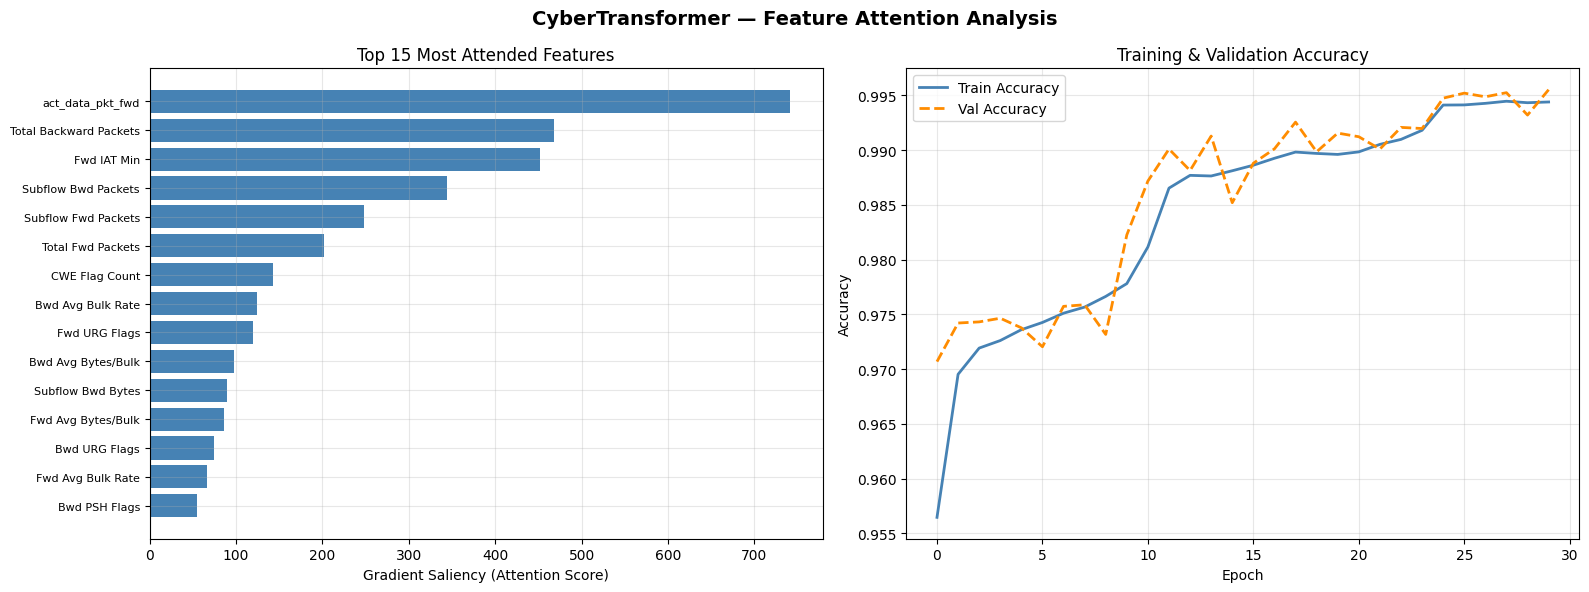

   Saved → transformer_attention.png


In [12]:
# -------------------------------------------------------------------------
# Step 6: Attention Visualization — What Did the Model Focus On?
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Hook to capture attention weights from the first transformer layer
attention_weights = []

def attention_hook(module, input, output):
    # TransformerEncoderLayer output is just the encoded tensor
    # We manually compute attention for visualization
    pass

# Get feature importance via gradient-based analysis (Saliency)
model.eval()
sample_x  = X_test_t[:1].clone().to(device).requires_grad_(True)
logit_out = model(sample_x)
top_class = logit_out.argmax(dim=1)
logit_out[0, top_class].backward()

saliency     = sample_x.grad.abs().squeeze().cpu().numpy()
feature_names = df.drop(columns=[target_col]).select_dtypes(
    include=[np.number]).columns.tolist()

top_n   = 15
top_idx = np.argsort(saliency)[-top_n:][::-1]
top_sal = saliency[top_idx]
top_fts = [feature_names[i] for i in top_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CyberTransformer — Feature Attention Analysis',
             fontsize=14, fontweight='bold')

# Plot 1: Top Features by Saliency
axes[0].barh(range(top_n), top_sal[::-1], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_fts[::-1], fontsize=8)
axes[0].set_title(f'Top {top_n} Most Attended Features')
axes[0].set_xlabel('Gradient Saliency (Attention Score)')
axes[0].grid(True, alpha=0.3)

# Plot 2: Training Accuracy Curve
axes[1].plot(train_accs, label='Train Accuracy', color='steelblue', linewidth=2)
axes[1].plot(val_accs,   label='Val Accuracy',   color='darkorange',
             linestyle='--', linewidth=2)
axes[1].set_title('Training & Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transformer_attention.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved → transformer_attention.png")


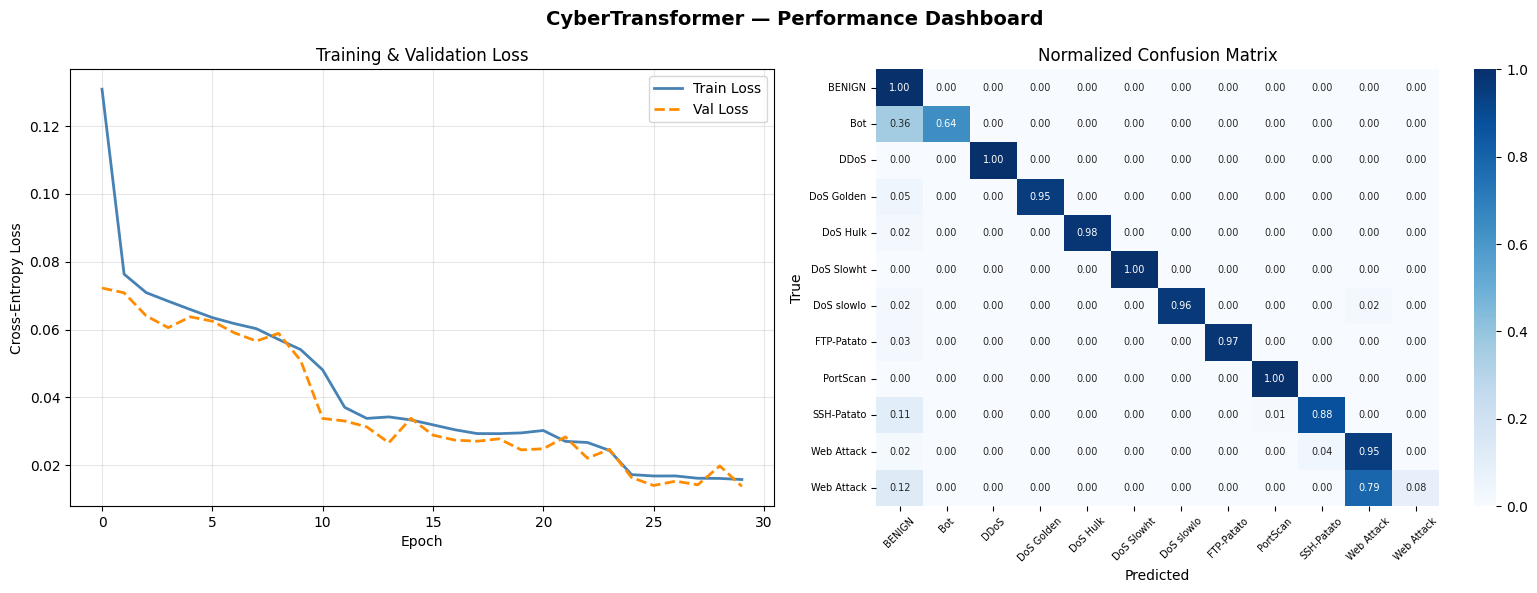

   Saved → transformer_performance.png

✅ Step 7 Execution Completed.


In [13]:
# -------------------------------------------------------------------------
# Step 7: Performance Metrics Dashboard
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CyberTransformer — Performance Dashboard',
             fontsize=14, fontweight='bold')

# Plot 1: Loss Curves
axes[0].plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(val_losses,   label='Val Loss',   color='darkorange',
             linestyle='--', linewidth=2)
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Confusion Matrix (top 10 classes for readability)
cm = confusion_matrix(all_labels, all_preds)
# Normalize for readability
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
    xticklabels=[c[:10] for c in class_names],
    yticklabels=[c[:10] for c in class_names],
    annot_kws={'size': 7}
)
axes[1].set_title('Normalized Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig('transformer_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved → transformer_performance.png")

print(f"\n✅ Step 7 Execution Completed.")

In [14]:
# -------------------------------------------------------------------------
# Step 8: Save Model, Scaler, Label Encoder & Metadata
# -------------------------------------------------------------------------
import joblib

torch.save({
    'model_state_dict' : model.state_dict(),
    'input_dim'        : input_dim,
    'num_classes'      : num_classes,
    'd_model'          : 64,
    'nhead'            : 4,
    'num_layers'       : 3,
    'class_names'      : class_names,
    'train_losses'     : train_losses,
    'val_losses'       : val_losses,
    'train_accs'       : train_accs,
    'val_accs'         : val_accs,
    'best_val_acc'     : best_val_acc,
}, 'cybershield_transformer.pth')

joblib.dump(scaler, 'transformer_scaler.pkl')
joblib.dump(le,     'transformer_label_encoder.pkl')

print("\n💾 Saved:")
print("   cybershield_transformer.pth       ← model weights + metadata")
print("   transformer_scaler.pkl            ← feature scaler")
print("   transformer_label_encoder.pkl     ← label encoder (class names)")
print("   transformer_attention.png         ← feature attention plot")
print("   transformer_performance.png       ← loss + confusion matrix")

print(f"\n{'='*55}")
print("  ✅ Transformer Module Complete — Ready for GUI")
print(f"{'='*55}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test F1-Score : {test_f1:.4f} (weighted)")
print(f"  Best Val Acc  : {best_val_acc*100:.2f}%")
print(f"  Classes       : {num_classes}")
print(f"  Epochs        : {len(train_losses)}")


💾 Saved:
   cybershield_transformer.pth       ← model weights + metadata
   transformer_scaler.pkl            ← feature scaler
   transformer_label_encoder.pkl     ← label encoder (class names)
   transformer_attention.png         ← feature attention plot
   transformer_performance.png       ← loss + confusion matrix

  ✅ Transformer Module Complete — Ready for GUI
  Test Accuracy : 99.56%
  Test F1-Score : 0.9954 (weighted)
  Best Val Acc  : 99.55%
  Classes       : 12
  Epochs        : 30
